In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
try:
    fraud_detection = pd.read_csv("creditcard.csv")
    print("Data loaded sucessfully")

except FileNotFoundError:
     print("Data is not loaded ")

Data loaded sucessfully


In [7]:
print("/n Data Summary:")
print(fraud_detection.info())

/n Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float6

## Handeling missing values

In [11]:
#any() -->to reduce eberything to a single True()
if (fraud_detection.isnull().sum()>0).any():
    print("Missing values found Filling with forward fill")
    fraud_detection.fillna(method = "ffill",inplace= True)

In [15]:
print(fraud_detection.columns.tolist())


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


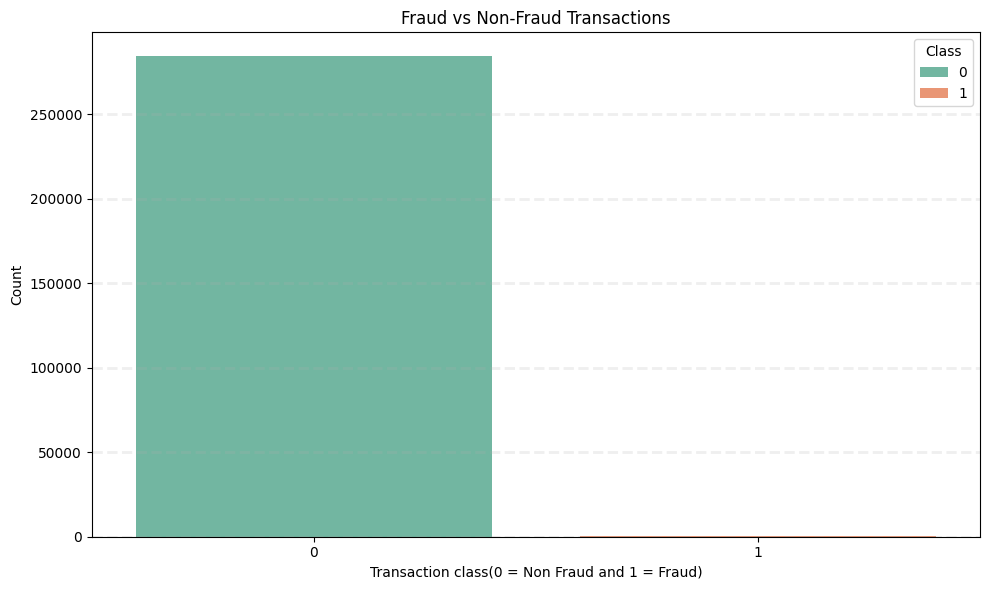

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data = fraud_detection,x= 'Class',hue='Class',palette = 'Set2')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction class(0 = Non Fraud and 1 = Fraud)")
plt.ylabel("Count")
plt.grid(axis = 'y',linestyle = '--',linewidth ='2',alpha =0.2 )
plt.tight_layout()
plt.show()

In [18]:
# taking out the correlation of the matrix

plt.figure(figsize=(10,6))
corr= fraud_detection.corr()

<Figure size 1000x600 with 0 Axes>

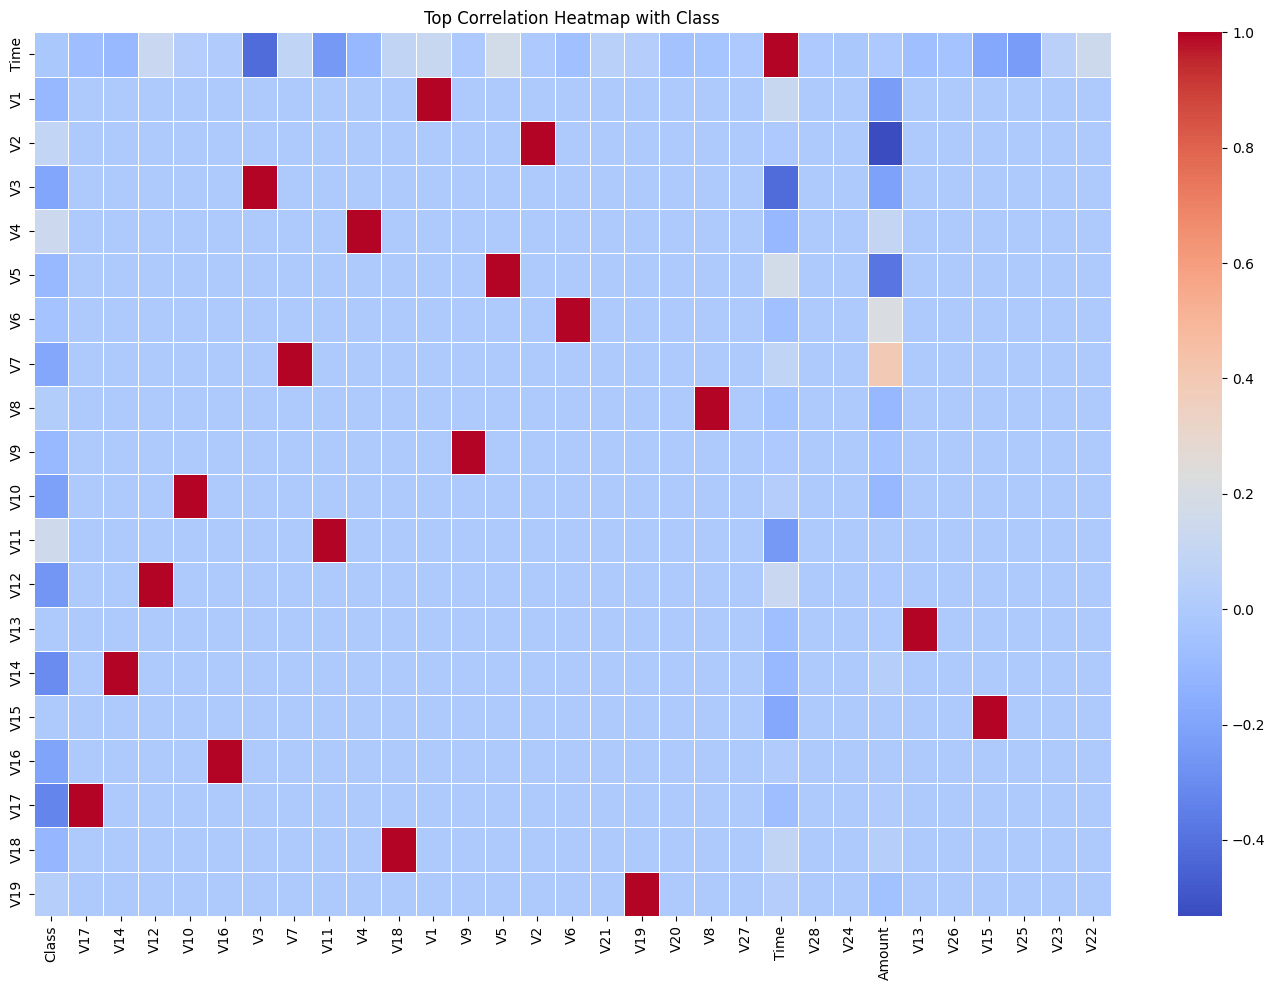

In [26]:
plt.figure(figsize=(14, 10)) 
#sort correlation with respect to 'Class' 
sorted_corr = corr['Class'].abs().sort_values(ascending = False)
sns.heatmap(corr[sorted_corr.index][:20],cmap='coolwarm',annot  =
           False,linewidth = 0.5)
plt.title("Top Correlation Heatmap with Class")
plt.tight_layout()
plt.show()
